In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
# Загрузка данных
df = pd.read_csv("athlete_events.csv")

# Просмотр первых нескольких строк данных
df.head()

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN


In [5]:
# Получаем информацию о данных
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271116 entries, 0 to 271115
Data columns (total 15 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   ID      271116 non-null  int64  
 1   Name    271116 non-null  object 
 2   Sex     271116 non-null  object 
 3   Age     261642 non-null  float64
 4   Height  210945 non-null  float64
 5   Weight  208241 non-null  float64
 6   Team    271116 non-null  object 
 7   NOC     271116 non-null  object 
 8   Games   271116 non-null  object 
 9   Year    271116 non-null  int64  
 10  Season  271116 non-null  object 
 11  City    271116 non-null  object 
 12  Sport   271116 non-null  object 
 13  Event   271116 non-null  object 
 14  Medal   39783 non-null   object 
dtypes: float64(3), int64(2), object(10)
memory usage: 31.0+ MB


In [6]:
# Получаем количество ненулевых значений для каждого признака
df.count()

ID        271116
Name      271116
Sex       271116
Age       261642
Height    210945
Weight    208241
Team      271116
NOC       271116
Games     271116
Year      271116
Season    271116
City      271116
Sport     271116
Event     271116
Medal      39783
dtype: int64

In [7]:
# Статистическая информация по числовым столбцам
df[['Age', 'Height', 'Weight']].describe()

,Age,Height,Weight
count,261642.000000,210945.000000,208241.000000
mean,25.556898,175.338970,70.702393
std,6.393561,10.518462,14.348020
min,10.000000,127.000000,25.000000
25%,21.000000,168.000000,60.000000
50%,24.000000,175.000000,70.000000
75%,28.000000,183.000000,79.000000
max,97.000000,226.000000,214.000000


In [8]:
# самый молодой участник 92
df_1992 = df[df['Year'] == 1992]
youngest_1992 = df_1992.loc[df_1992['Age'].idxmin()]
youngest_1992[['Name', 'Age', 'Event']]

Name     Carlos Bienvenido Front Barrera
Age                                 11.0
Event          Rowing Men's Coxed Eights
Name: 73461, dtype: object

In [9]:
# уникальные виды спорта
sports_list = df['Sport'].unique()
sports_list

array(['Basketball', 'Judo', 'Football', 'Tug-Of-War', 'Speed Skating',
       'Cross Country Skiing', 'Athletics', 'Ice Hockey', 'Swimming',
       'Badminton', 'Sailing', 'Biathlon', 'Gymnastics',
       'Art Competitions', 'Alpine Skiing', 'Handball', 'Weightlifting',
       'Wrestling', 'Luge', 'Water Polo', 'Hockey', 'Rowing', 'Bobsleigh',
       'Fencing', 'Equestrianism', 'Shooting', 'Boxing', 'Taekwondo',
       'Cycling', 'Diving', 'Canoeing', 'Tennis', 'Modern Pentathlon',
       'Figure Skating', 'Golf', 'Softball', 'Archery', 'Volleyball',
       'Synchronized Swimming', 'Table Tennis', 'Nordic Combined',
       'Baseball', 'Rhythmic Gymnastics', 'Freestyle Skiing',
       'Rugby Sevens', 'Trampolining', 'Beach Volleyball', 'Triathlon',
       'Ski Jumping', 'Curling', 'Snowboarding', 'Rugby',
       'Short Track Speed Skating', 'Skeleton', 'Lacrosse', 'Polo',
       'Cricket', 'Racquets', 'Motorboating', 'Military Ski Patrol',
       'Croquet', 'Jeu De Paume', 'Roque', 'Al

In [16]:
# Фильтрация данных по году, полу и виду спорта
df_2000_women_tennis = df[(df['Year'] == 2000) & (df['Sex'] == 'F') & (df['Sport'] == 'Tennis')]

# Средний рост теннисисток
avg_height_tennis_2000 = df_2000_women_tennis['Height'].mean()
print(f'Средний рост тенесисток на ОИ в 2000 году: {avg_height_tennis_2000} см')

Средний рост тенесисток на ОИ в 2000 году: 171.792 см


In [14]:
# Фильтрация данных по году, виду спорта и стране
df_2008_table_tennis_china = df[(df['Year'] == 2008) & (df['Sport'] == 'Table Tennis') & (df['NOC'] == 'CHN')]

# Подсчитаем количество золотых медалей
gold_medals_china = df_2008_table_tennis_china[df_2008_table_tennis_china['Medal'] == 'Gold'].shape[0]
print(f'Кол-во золотых медалей у сборной Китая: {gold_medals_china}')

Кол-во золотых медалей у сборной Китая: 8


In [13]:
# Фильтрация данных по летним ОИ 2004 и 1988 годов
df_summer_2004 = df[(df['Year'] == 2004) & (df['Season'] == 'Summer')]
df_summer_1988 = df[(df['Year'] == 1988) & (df['Season'] == 'Summer')]

# Подсчет уникальных видов спорта
sports_2004 = df_summer_2004['Sport'].nunique()
sports_1988 = df_summer_1988['Sport'].nunique()

print(f'Кол-во уникальных видов спорт на ОИ 2004: {sports_2004}')
print(f'Кол-во уникальных видов спорт на ОИ 1988: {sports_1988}')
print(f'Разница: {sports_2004 - sports_1988}')

Кол-во уникальных видов спорт на ОИ 2004: 34
Кол-во уникальных видов спорт на ОИ 1988: 27
Разница: 7


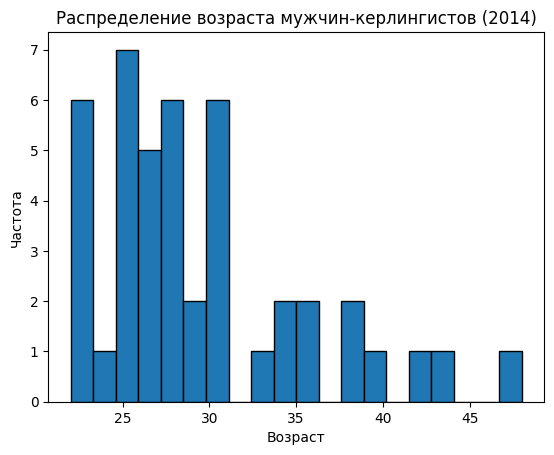

In [18]:
import matplotlib.pyplot as plt

df_2014_men_curling = df[(df['Year'] == 2014) & (df['Sport'] == 'Curling') & (df['Sex'] == 'M')]

plt.hist(df_2014_men_curling['Age'], bins=20, edgecolor='black')
plt.title('Распределение возраста мужчин-керлингистов (2014)')
plt.xlabel('Возраст')
plt.ylabel('Частота')
plt.show()

In [19]:
df_2006_winter = df[(df['Year'] == 2006) & (df['Season'] == 'Winter')]

medals_and_age = df_2006_winter.groupby('NOC').agg(
    medals=('Medal', 'count'),
    avg_age=('Age', 'mean')
).reset_index()

medals_and_age[medals_and_age['medals'] > 0]

,NOC,medals,avg_age
5,AUS,2,25.711111
6,AUT,30,27.704545
11,BLR,1,27.142857
13,BUL,1,26.181818
14,CAN,69,25.481967
16,CHN,13,23.534247
18,CRO,3,22.760870
20,CZE,27,26.276471
23,EST,3,25.634921
25,FIN,41,26.614286


In [20]:
# сводная таблица по медалям
medals_pivot = pd.pivot_table(
    df_2006_winter[df_2006_winter['Medal'] != 'NA'],
    values='ID',
    index='NOC',
    columns='Medal',
    aggfunc='count',
    fill_value=0
)

medals_pivot

Medal,Bronze,Gold,Silver
NOC,,,
AUS,1,1,0
AUT,7,16,7
BLR,0,0,1
BUL,0,0,1
CAN,11,30,28
CHN,6,2,5
CRO,0,1,2
CZE,24,1,2
EST,0,3,0
